# Recreating a GPT from scratch

In this notebook, I will be showing how GPT-2 can be recreated from scratch using **PyTorch**. While I will maintain a didactic tone to explain what I am doing, some knowledge of deep learning and linear algebra is expected to understand this notebook.

---

Note: GPT-2 is a model from 2019, back when they weren't *that big* and I am just a signle guy with a laptop, not a multi-billion dollar bubble. It will work, but don't expect anything close to competing with SoTA models.

## Basic setup

We will first establish the important hyperparameters to mimic the original GPT-2's configuration as closely as possible.

---

In [1]:
import tiktoken

# It is not exctly the same as original GPT-2, but I need this to run on a single small GPU...
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

# This is just to guarantee the same tokenization
# There is not much difficulty in the tokenizer, its just BPE
tokenizer = tiktoken.get_encoding("gpt2")

## Define the individual building blocks

Next up, we will define some of the important parts which are necessary for running the neural network.

---

### Layer Norm

First, we can begin by defining the `LayerNorm` module. This is important because if we allow the individual internal state vector items to do anything they want independently of the rest of the vector, their effect on the gradient might lead to some unreasonably large or close-to-zero values which will make convergence impossible.

Therefore, what we are doing here is a bit of applied statistics to make sure that the individual items form a standard normal distribution N($\mu$=0, σ=1).

In [2]:
import torch
import torch.nn as nn

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):

        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        var += self.eps
        norm_x = (x - mean) / torch.sqrt(var)

        return self.scale * norm_x + self.shift

We can examine how it works by looking at the distribution with and without the `LayerNorm` module.

In [3]:
batch_example = torch.randn(2, 5)

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)

mean = out.mean(dim=-1, keepdim=True)
std = out.std(dim=-1, unbiased=False, keepdim=True)

print("Without LayerNorm, the distribution looks like so: ")
print(30*"-")
print(f"mu = {mean}")
print(f"sigma = {std}")


print("\n" + 30*"=" + "\n")

ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)

mean = out_ln.mean(dim=-1, keepdim=True)
std = out_ln.std(dim=-1, unbiased=False, keepdim=True)

print("With LayerNorm, the distribution looks like so: ")
print(30*"-")
print(f"mu = {mean}")
print(f"sigma = {std}")

Without LayerNorm, the distribution looks like so: 
------------------------------
mu = tensor([[0.1624],
        [0.1130]], grad_fn=<MeanBackward1>)
sigma = tensor([[0.2026],
        [0.1960]], grad_fn=<StdBackward0>)


With LayerNorm, the distribution looks like so: 
------------------------------
mu = tensor([[0.],
        [0.]], grad_fn=<MeanBackward1>)
sigma = tensor([[1.0000],
        [1.0000]], grad_fn=<StdBackward0>)


### Multi-Headed Self Attention (MHSA)

This is what makes the transformer a transformer, what gives it the contaxtual comprehention capabilities and what gave me the biggest headache when I first learned about this topic. The theoretical explanation of why this works would make for a very long notebook, but if this is new to you, I recommend the [3Blue1Brown video](https://www.youtube.com/watch?v=eMlx5fFNoYc).

Note that I will be implementing the mechanism using 4D tensors for efficiency reasons. As this is not the easiest thing to wrap our 3D heads around, here is the step-by-step of how everything works:

1. We start with an input tensor of dimensions $[batch\_size, n\_tokens, embedding\_dim]$.
2. This gets multiplied by the three `query`, `key` and `value` matrices, each of dimensionality $[embedding\_dim, qkv\_dim]$, resulting in three new tensors, each of dimensionality $[batch\_size, n\_tokens, qkv\_dim]$. Each stores one of the 3 representations and I will be calling them `queries`, `keys` and `values`.
3. The last dimension then gets split into the heads, so the tensors end up with the following dimensions $[batch\_size, n\_tokens, n\_heads, head\_dim]$ where $n\_heads$ is the number of heads and $head\_dim$ is the dimensionality of each head.
4. We then transpose the second and a third dimension, so that the dimensionality now looks like this: $[batch\_size, n\_heads, n\_tokens, head\_dim]$.
5. Now, we have all the tensors we want in the correct format, so we need to start using them. We need to get the dot product of the `queries` and `keys`. To do this, we transpose the third and fourth dimensions of the `keys` tensor and multiply it with `queries`. That is, we are multiplying $queries[batch\_size, n\_heads, n\_tokens, head\_dim] \cdot keys[batch\_size, n\_heads, head\_dim, n\_tokens]$. The first two dimensions $[batch\_size, n\_heads]$ sort of act as a 2-level nested loop, while the remaining two are essentially doing a matrix-matrix multiplication on every iteration of the inside loop with the following dimensionality: $[n\_tokens, head\_dim] \cdot [head\_dim, n\_tokens]$. This elegantly returns a matrix of $[n\_tokens, n\_tokens]$ dimensionality, that is, the basic self-attention matrix. The final dimensionality of the `attention scores` tensor is therefore $[batch\_size, n\_heads, n\_tokens, n\_tokens]$.
6. We then apply Softmax by row to this tensor divided by the square root of qkv dimensionality. (I am going to clarify, because there are a lot of dimensions floating around here, by qkv dimensionality, I mean the number dimensions of a single qkv vector in a single head. We divide by a scalar.)
7. We then multiply the `attention scores` tensor by the `values` tensor, that is, $attn[batch\_size, n\_heads, n\_tokens, n\_tokens] \cdot values[batch\_size, n\_heads, n\_tokens, head\_dim]$. This returns the `attention weights` tensor, which has dimensions$[batch\_size, n\_heads, n\_tokens, head\_dim]$.
8. In order to extract the context vectors for the individual tokens from this tensor, we need to transpose back to the original tensor dimensionality, that is we transpose the second and third dimensions and `attention weights` becomes $[batch\_size, n\_tokens, n\_heads, head\_dim]$.
9. We then combine the heads back together and the dimensionality becomes $[batch\_size, n\_tokens, qkv\_dim]$.
10. We then multiply this by the linear projection matrix to make sure that the heads' outputs actually work well together as a representation.
11. And thus, we end up with a tensor of contextualised representations of the tokens where the last dimension is the dimension of the contextual representation with the same dimensionality as $embeddin\_dim$.

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):

        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        batch_d, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(batch_d, num_tokens, self.num_heads, self.head_dim)
        values = values.view(batch_d, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(batch_d, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention
        attn_scores = queries @ keys.transpose(2, 3)

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(batch_d, num_tokens, self.d_out)

        context_vec = self.out_proj(context_vec)

        return context_vec

### Feed Forward Neural Network

Next up, we will define the feed forward network, which will process the tokens on an individual level, which is very helpful for storing factual information in the memory of the transformer. Mathematically, it is quite analogous to a multi-layer perceptron.

In [5]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
      super().__init__()
      hidden_state_dim = cfg["emb_dim"]*4

      self.upscale = nn.Linear(cfg["emb_dim"], hidden_state_dim)
      self.downscale = nn.Linear(hidden_state_dim, cfg["emb_dim"],)
      self.gelu = GELU()

    def forward(self, x):
      x = self.upscale(x)
      x = self.gelu(x)
      x = self.downscale(x)

      return x

### Transformer block

Finally, we will put all of these building blocks together to create a transformer block. On a high level, we can imagine the logic of what is happening like this:

1. A set of embeddings comes into the block

2. We apply layer normalisation to it in order to stabilise the gradients

3. We send it to MHSA to figgure out how the tokens are related to each other

4. We sum this representation to the original set of embeddings in order to not lose the previous meaning

5. We apply layer normalisation again for the same reasons as before

6. We send it to the feed forward network in order to process the contextual token representations individually

7. We sum it to the MHSA output, once again, in order to not lose previous information. This sum is the output of the transofrmer block.

![transformer_block.png](transformer_block.png)

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.mhsa = MultiHeadAttention(d_in=cfg["emb_dim"],
                                       d_out=cfg["emb_dim"],
                                       context_length=cfg["context_length"],
                                       dropout=cfg["drop_rate"],
                                       num_heads=cfg["n_heads"])
        self.ffn = FeedForward(cfg)
        self.layer_norm1 = LayerNorm(cfg["emb_dim"])
        self.layer_norm2 = LayerNorm(cfg["emb_dim"])
        self.dropout1 = nn.Dropout(cfg["drop_rate"])
        self.dropout2 = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        shortcut = x
        x = self.layer_norm1(x)
        x = self.mhsa(x)
        x = self.dropout1(x)
        x = x + shortcut

        shortcut = x
        x = self.layer_norm2(x)
        x = self.ffn(x)
        x = self.dropout2(x)
        x = x + shortcut

        return x

### Define the full GPT architecture

The architecture boils down into a sequence of 12 transformer blocks, one more layer normalization and a final dense layer projection into the vocabulary size.

In [7]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

We can then define a simple generation function with Softmax.

In [8]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        probas = torch.softmax(logits, dim=-1)

        idx_next = torch.argmax(probas, dim=-1, keepdim=True)

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

And use it to generate text. However, note that since we haven't yet started training, this will just be a string of random tokens.

In [9]:
model = GPTModel(GPT_CONFIG_124M)

start_context = "The sentence starts by"

encoded = tokenizer.encode(start_context)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

The sentence starts by �vid warn detail XL economies


## Training

In this section, we will find the optimal parameters for the parameters we defined in the forward pass above.

---

### Dataset

First, we will define a dataset, an by define, I mean download The Verdict.

In [10]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

print(f"Length of text data: {len(text_data)} characters")

total_tokens = len(tokenizer.encode(text_data))
print(f"Total number of tokens in text data: {total_tokens}")

# We will simply split into training and validation
split_idx = int(0.9 * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

Length of text data: 20479 characters
Total number of tokens in text data: 5145


And of course, we will need to turn it into a dataloader and define a couple of utility functions while we are at it:

In [11]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={""})
        assert len(token_ids) > max_length, "Number of tokenized inputs must at least be equal to max_length+1"

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    pass

def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):

    tokenizer = tiktoken.get_encoding("gpt2")

    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


### Training loop

Now that the data looks as it should, we can proceed to defining the training loop and the corresponding utility functions:

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):

    track_tokens_seen = []
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:

            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

        if epoch % eval_freq == 0:
          train_loss, val_loss = evaluate_model(model,
                                                train_loader,
                                                val_loader,
                                                device,
                                                eval_iter)

          train_losses.append(train_loss)
          val_losses.append(val_loss)

          print(50*"-")
          print(f"Epoch {epoch}: \n train_loss = {train_loss} \n val_loss = {val_loss}")
          print(50*"-")
          print("Example generation:")
          generate_and_print_sample(model, tokenizer, device, start_context)
          print(50*"-")

    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show()



And just like that we can start training:

In [13]:
import time

device = "cuda"

start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 20
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="The thing about turtles", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

--------------------------------------------------
Epoch 0: 
 train_loss = 7.337253284454346 
 val_loss = 7.473145961761475
--------------------------------------------------
Example generation:
The thing about turtles,,,,,,,,,,,,.                                     
--------------------------------------------------
--------------------------------------------------
Epoch 5: 
 train_loss = 3.042466735839844 
 val_loss = 6.206931114196777
--------------------------------------------------
Example generation:
The thing about turtles I had been, and pushed one of the to the fact of the last I had been--and by me to have to have to see it.                    
--------------------------------------------------
--------------------------------------------------
Epoch 10: 
 train_loss = 0.28063764572143557 
 val_loss = 6.551052093505859
--------------------------------------------------
Example generation:
The thing about turtles?"  "Yes--quite insensible to the irony. She wanted him vindic

We can also visualise the evolution of loss during the training process:

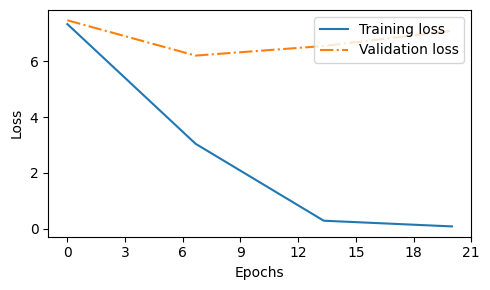

In [14]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

We can see, quite reasonably so, given the size of our dataset, that the model starts overfitting relatively soon, however, the loss decrease is still significant enough for it to produce sensible results. While the text below is not that impressive in terms of its contents, it written using very good English grammar:

In [15]:
start_context = "This is interesting because"
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0).to(device)

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"]
)

decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

This is interesting because he'd never touched a brush."

And his tone told me in a flash that he never


## Conclusions

---

What we end up with is an LLM, be it a rather small one. As of now, it is not that intelligent because of my hardware and data limitations and it is also not trained for maintaining conversations. Nevertheless it is perfectly serviceable as a standard language model inside other systems like Automatic Speech Recognition and it could very easily be adopted for other NLP tasks like sentiment analysis.